<a href="https://colab.research.google.com/github/DaniloHonda/Calculadora-PHP/blob/master/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt

In [7]:
# Link direto para o arquivo CSV público no GitHub
url_base = "https://raw.githubusercontent.com/MLRG-CEFET-RJ/ml-class/master/datasets/play_tennis.csv"

# O Pandas vai baixar e ler o arquivo automaticamente
dataset = pd.read_csv(url_base)

# Visualizando os dados para você entender a estrutura
display(dataset.head())

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [8]:
# A coluna 'day' (dia 1, dia 2) não ajuda a prever nada, então tiramos ela
# As colunas que vão ser analisadas pela árvore (X)
X = dataset[['outlook', 'temp', 'humidity', 'wind']]

# O que a árvore precisa prever (y), que é a coluna 'play' (Yes / No)
y = dataset[['play']]

# Transformando os textos (Sunny, Rainy, High, Normal) em números (0 e 1)
X_processado = pd.get_dummies(X, drop_first=True)

display(X_processado.head())

,outlook_Rain,outlook_Sunny,temp_Hot,temp_Mild,humidity_Normal,wind_Weak
0,False,True,True,False,False,True
1,False,True,True,False,False,False
2,False,False,True,False,False,True
3,True,False,False,True,False,True
4,True,False,False,False,True,True


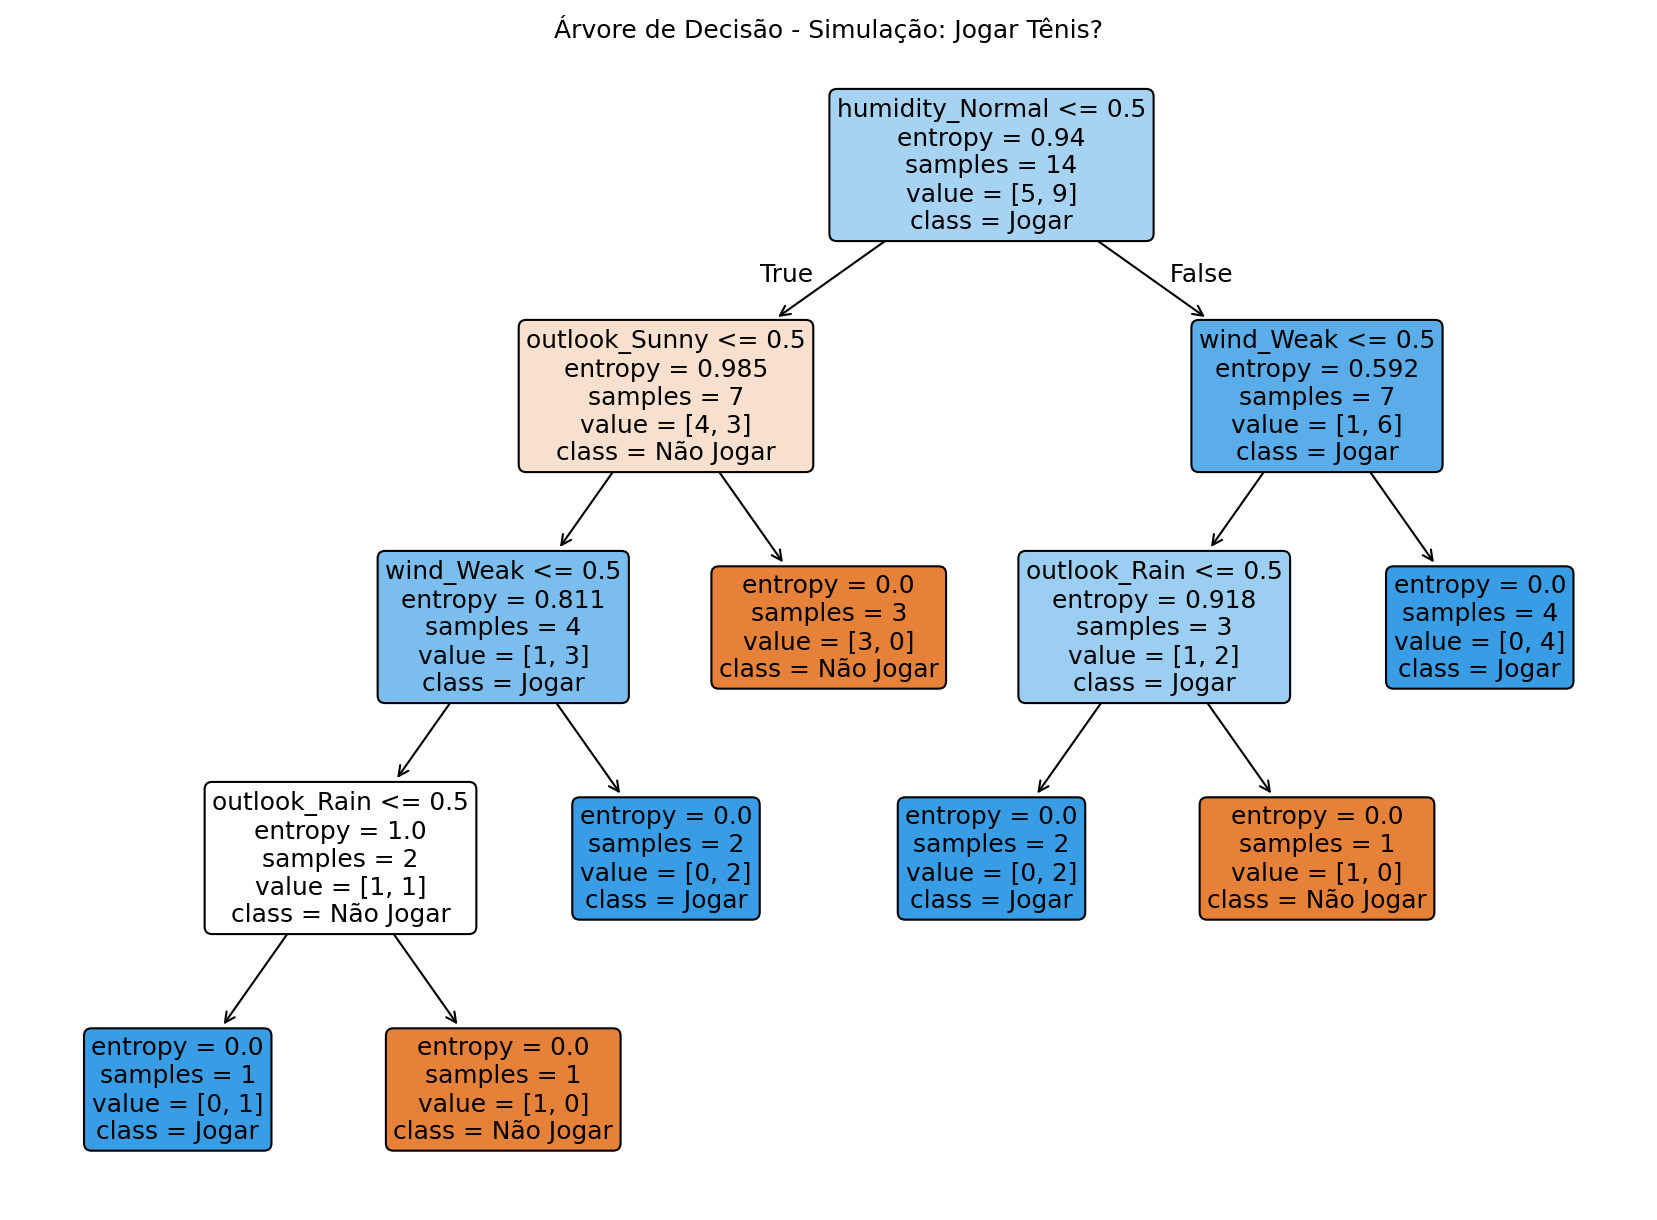

In [9]:
# Criação e treinamento do modelo de Árvore de Decisão
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(X_processado, y)

# Configuração do visual do gráfico
plt.figure(figsize=(14, 10), dpi=150)
tree.plot_tree(clf,
               feature_names=X_processado.columns.tolist(),
               class_names=['Não Jogar', 'Jogar'], # Nomes amigáveis para as classes Yes/No
               filled=True,
               rounded=True)

plt.title("Árvore de Decisão - Simulação: Jogar Tênis?")
plt.show()